In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape, LeakyReLU
from tensorflow.keras.optimizers import Adam

In [2]:
# -------------------------------
(X_train, _), (_, _) = mnist.load_data()

# Normalize to [-1, 1] (IMPORTANT)
X_train = (X_train - 127.5) / 127.5

# Reshape
X_train = X_train.reshape(-1, 28, 28, 1)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
def build_generator():
    model = Sequential()

    model.add(Dense(256, input_dim=100))
    model.add(LeakyReLU(0.2))

    model.add(Dense(512))
    model.add(LeakyReLU(0.2))

    model.add(Dense(784, activation='tanh'))
    model.add(Reshape((28, 28, 1)))

    return model

In [4]:
def build_discriminator():
    model = Sequential()

    model.add(Flatten(input_shape=(28, 28, 1)))
    model.add(Dense(512))
    model.add(LeakyReLU(0.2))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(0.0002),
        metrics=['accuracy']
    )

    return model


In [5]:
generator = build_generator()
discriminator = build_discriminator()

# Freeze discriminator when training GAN
discriminator.trainable = False

gan = Sequential([generator, discriminator])

gan.compile(
    loss='binary_crossentropy',
    optimizer=Adam(0.0002)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
epochs = 20000
batch_size = 64

for epoch in range(epochs):

    # -------------------
    # Train Discriminator
    # -------------------
    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_imgs = X_train[idx]

    noise = np.random.normal(0, 1, (batch_size, 100))
    fake_imgs = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((batch_size,1)))
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((batch_size,1)))

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


KeyboardInterrupt: 

In [ ]:
    noise = np.random.normal(0, 1, (batch_size, 100))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size,1)))

    # -------------------
    # Print & Visualize
    # -------------------
    if epoch % 1000 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss_real[0]:.4f} | G Loss: {g_loss:.4f}")

        # Generate images
        noise = np.random.normal(0, 1, (16, 100))
        gen_imgs = generator.predict(noise)

        # Rescale back to [0,1] for display
        gen_imgs = 0.5 * gen_imgs + 0.5

        fig, axs = plt.subplots(4, 4, figsize=(5,5))
        cnt = 0
        for i in range(4):
            for j in range(4):
                axs[i,j].imshow(gen_imgs[cnt,:,:,0], cmap='gray')
                axs[i,j].axis('off')
                cnt += 1
        plt.show()


Epoch 0/3000
D Loss: 0.8461
D Accuracy: 26.95%
G Loss: 0.7039


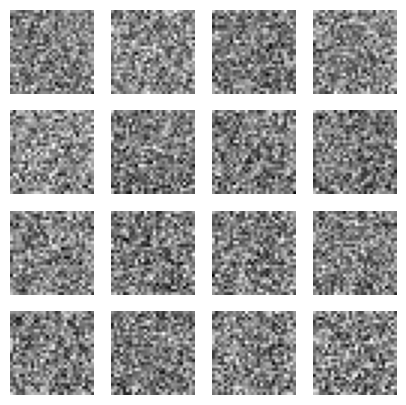


Epoch 100/3000
D Loss: 0.2637
D Accuracy: 88.91%
G Loss: 1.6892

Epoch 200/3000
D Loss: 0.1511
D Accuracy: 94.34%
G Loss: 2.8020

Epoch 300/3000
D Loss: 0.1053
D Accuracy: 96.22%
G Loss: 3.3321

Epoch 400/3000
D Loss: 0.0838
D Accuracy: 97.16%
G Loss: 3.5552

Epoch 500/3000
D Loss: 0.0721
D Accuracy: 97.73%
G Loss: 3.6838


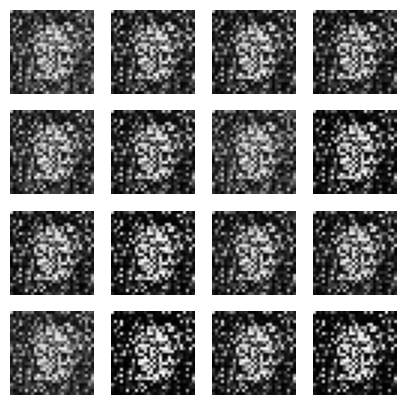


Epoch 600/3000
D Loss: 0.0666
D Accuracy: 98.10%
G Loss: 3.7468

Epoch 700/3000
D Loss: 0.0641
D Accuracy: 98.35%
G Loss: 3.7605

Epoch 800/3000
D Loss: 0.0628
D Accuracy: 98.54%
G Loss: 3.7515

Epoch 900/3000
D Loss: 0.0660
D Accuracy: 98.65%
G Loss: 3.6943

Epoch 1000/3000
D Loss: 0.0677
D Accuracy: 98.72%
G Loss: 3.6498


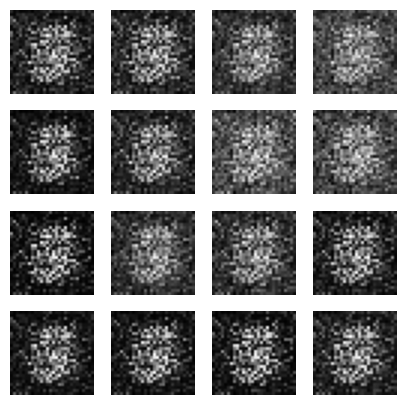


Epoch 1100/3000
D Loss: 0.0704
D Accuracy: 98.76%
G Loss: 3.5979

Epoch 1200/3000
D Loss: 0.0737
D Accuracy: 98.78%
G Loss: 3.5371

Epoch 1300/3000
D Loss: 0.0764
D Accuracy: 98.80%
G Loss: 3.4693

Epoch 1400/3000
D Loss: 0.0845
D Accuracy: 98.74%
G Loss: 3.3725

Epoch 1500/3000
D Loss: 0.0872
D Accuracy: 98.74%
G Loss: 3.3177


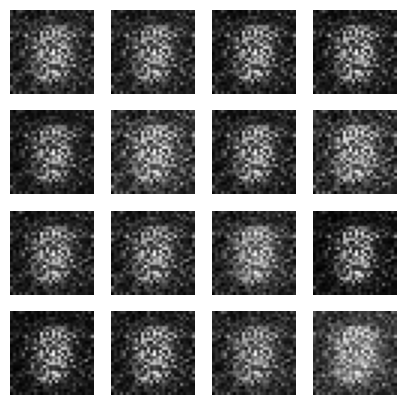


Epoch 1600/3000
D Loss: 0.0856
D Accuracy: 98.80%
G Loss: 3.3010

Epoch 1700/3000
D Loss: 0.0850
D Accuracy: 98.86%
G Loss: 3.2801

Epoch 1800/3000
D Loss: 0.0850
D Accuracy: 98.88%
G Loss: 3.2568

Epoch 1900/3000
D Loss: 0.0854
D Accuracy: 98.89%
G Loss: 3.2383

Epoch 2000/3000
D Loss: 0.0848
D Accuracy: 98.91%
G Loss: 3.2296


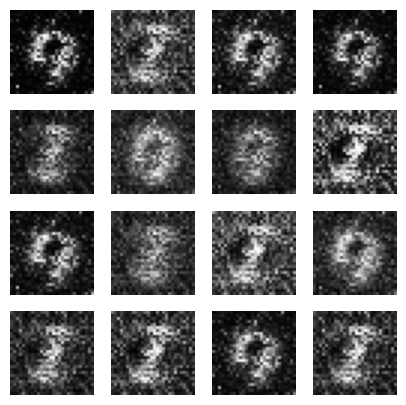


Epoch 2100/3000
D Loss: 0.0848
D Accuracy: 98.93%
G Loss: 3.2201

Epoch 2200/3000
D Loss: 0.0841
D Accuracy: 98.94%
G Loss: 3.2227

Epoch 2300/3000
D Loss: 0.0833
D Accuracy: 98.96%
G Loss: 3.2287

Epoch 2400/3000
D Loss: 0.0835
D Accuracy: 98.95%
G Loss: 3.2322

Epoch 2500/3000
D Loss: 0.0839
D Accuracy: 98.93%
G Loss: 3.2317


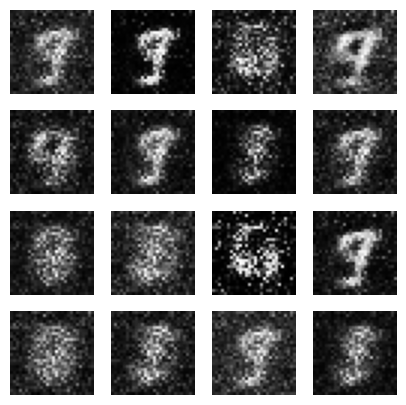


Epoch 2600/3000
D Loss: 0.0842
D Accuracy: 98.91%
G Loss: 3.2349

Epoch 2700/3000
D Loss: 0.0859
D Accuracy: 98.84%
G Loss: 3.2319

Epoch 2800/3000
D Loss: 0.0871
D Accuracy: 98.80%
G Loss: 3.2242

Epoch 2900/3000
D Loss: 0.0887
D Accuracy: 98.75%
G Loss: 3.2117


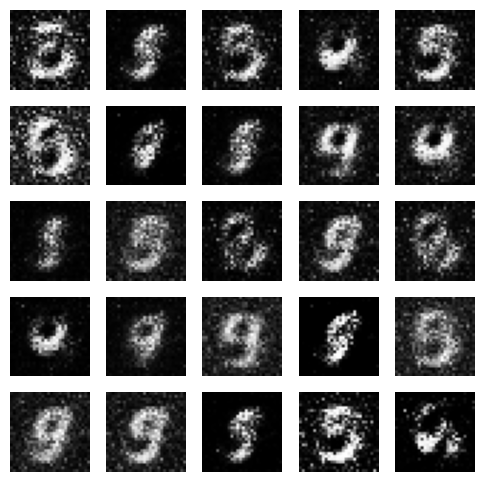

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape, LeakyReLU
from tensorflow.keras.optimizers import Adam

# =====================================================
# LOAD DATA
# =====================================================

(X_train, _), (_, _) = mnist.load_data()

# Normalize images to [-1, 1]
X_train = (X_train - 127.5) / 127.5

# Reshape to (28,28,1)
X_train = X_train.reshape(-1, 28, 28, 1)

# =====================================================
# GENERATOR
# =====================================================

def build_generator():

    model = Sequential()

    model.add(Dense(256, input_dim=100))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(512))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(784, activation='tanh'))

    model.add(Reshape((28, 28, 1)))

    return model

# =====================================================
# DISCRIMINATOR
# =====================================================

def build_discriminator():

    model = Sequential()

    model.add(Flatten(input_shape=(28, 28, 1)))

    model.add(Dense(512))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(0.0002),
        metrics=['accuracy']
    )

    return model

# =====================================================
# BUILD MODELS
# =====================================================

generator = build_generator()

discriminator = build_discriminator()

# Freeze discriminator while training GAN
discriminator.trainable = False

gan = Sequential([generator, discriminator])

gan.compile(
    loss='binary_crossentropy',
    optimizer=Adam(0.0002)
)

# Enable discriminator again for separate training
discriminator.trainable = True

# =====================================================
# TRAINING
# =====================================================

epochs = 3000
batch_size = 64

for epoch in range(epochs):

    # ==========================================
    # TRAIN DISCRIMINATOR
    # ==========================================

    # Select real images
    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_imgs = X_train[idx]

    # Generate fake images
    noise = np.random.normal(0, 1, (batch_size, 100))

    fake_imgs = generator.predict(noise, verbose=0)

    # Labels
    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))

    # Train discriminator
    d_loss_real = discriminator.train_on_batch(real_imgs, real_labels)

    d_loss_fake = discriminator.train_on_batch(fake_imgs, fake_labels)

    # Average discriminator loss
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # ==========================================
    # TRAIN GENERATOR
    # ==========================================

    noise = np.random.normal(0, 1, (batch_size, 100))

    misleading_labels = np.ones((batch_size, 1))

    discriminator.trainable = False

    g_loss = gan.train_on_batch(noise, misleading_labels)

    discriminator.trainable = True

    # ==========================================
    # PRINT PROGRESS
    # ==========================================

    if epoch % 100 == 0:

        print(f"\nEpoch {epoch}/{epochs}")

        print(f"D Loss: {d_loss[0]:.4f}")

        print(f"D Accuracy: {100 * d_loss[1]:.2f}%")

        print(f"G Loss: {g_loss:.4f}")

    # ==========================================
    # SHOW GENERATED IMAGES
    # ==========================================

    if epoch % 500 == 0:

        noise = np.random.normal(0, 1, (16, 100))

        gen_imgs = generator.predict(noise, verbose=0)

        # Rescale to [0,1]
        gen_imgs = 0.5 * gen_imgs + 0.5

        fig, axs = plt.subplots(4, 4, figsize=(5, 5))

        cnt = 0

        for i in range(4):
            for j in range(4):

                axs[i, j].imshow(
                    gen_imgs[cnt, :, :, 0],
                    cmap='gray'
                )

                axs[i, j].axis('off')

                cnt += 1

        plt.show()

# =====================================================
# FINAL GENERATION
# =====================================================

noise = np.random.normal(0, 1, (25, 100))

generated_images = generator.predict(noise, verbose=0)

generated_images = 0.5 * generated_images + 0.5

fig, axs = plt.subplots(5, 5, figsize=(6, 6))

cnt = 0

for i in range(5):
    for j in range(5):

        axs[i, j].imshow(
            generated_images[cnt, :, :, 0],
            cmap='gray'
        )

        axs[i, j].axis('off')

        cnt += 1

plt.show()